# GBSV MC2 - part 3: Data Augmentation

## Day 11: Define Augmentation Procedures
According to href{https://journalofbigdata.springeropen.com/articles/10.1186/s40537-019-0197-0} there are numerous ways how to augment data. Based on the linked survey, I chose 2 procedures for my use-case (which will be detecting birds in the wild):

1. **Random Erasing**: Randomly erases a rectangular region of the image and fills it with random noise. I am chosing this method as it is especially helpful for handling occlusion. As my use-case will be identifying birds in the wild, chances are images would have some occlusion by branches or leaves.

2. **Adding noise**: Adding gaussian noise to the image. I am choosing this method as it is a common augmentation technique that can help improve the robustness of the model by making it less sensitive to small variations in the input data.


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def show_images(images, titles):
    plt.figure(figsize=(15, 5))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

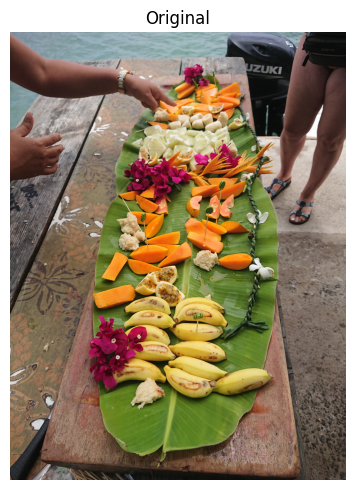

In [3]:
fruits = cv.imread('images/fruits.JPG')
fruits = cv.cvtColor(fruits, cv.COLOR_BGR2RGB)
show_images([fruits], ['Original'])

In [4]:
def random_erasing(img, erasing_prob=0.5, min_pct=0.02, max_pct=0.2, min_aspect_ratio=0.3):
    """
    Randomly erases a rectangular region of the image and fills it with random noise.
    Args:
        img (numpy.ndarray): Input image.
        erasing_prob (float): Probability of applying random erasing.
        min_pct (float): Minimum percentage of the image area to be erased.
        max_pct (float): Maximum percentage of the image area to be erased.
        min_aspect_ratio (float): Minimum aspect ratio of the erased region.
    """
    img_h, img_w, img_c = img.shape
    img = img.copy()

    if np.random.rand() > erasing_prob:
        return img

    for _ in range(100):
        target_area = np.random.uniform(min_pct, max_pct) * img_h * img_w
        aspect_ratio = np.random.uniform(min_aspect_ratio, 1/min_aspect_ratio)

        h = int(round(np.sqrt(target_area * aspect_ratio)))
        w = int(round(np.sqrt(target_area / aspect_ratio)))

        if h < img_h and w < img_w:
            x1 = np.random.randint(0, img_h - h)
            y1 = np.random.randint(0, img_w - w)

            noise = np.random.randint(0, 256, (h, w, img_c), dtype=np.uint8)
            img[x1:x1+h, y1:y1+w] = noise
            return img

    return img

random_erased = random_erasing(fruits, erasing_prob=1, min_pct=0.12, max_pct=0.20)

In [7]:
def add_salt_and_pepper_noise(img, amount=0.1, salt_vs_pepper=0.5):
    """
    Add salt and pepper noise to an image.
    Args:
        img (numpy.ndarray): Input image.
        amount (float): Proportion of pixels to be replaced with noise.
        salt_vs_pepper (float): Proportion of salt vs pepper noise.
    """
    noisy = img.copy()
    h, w, c = img.shape
    num_pixels = int(amount * h * w)

    # Salt noise (white pixels)
    num_salt = int(salt_vs_pepper * num_pixels)
    coords_salt = [np.random.randint(0, i, num_salt) for i in (h, w)]
    noisy[coords_salt[0], coords_salt[1]] = 255

    # Pepper noise (black pixels)
    num_pepper = num_pixels - num_salt
    coords_pepper = [np.random.randint(0, i, num_pepper) for i in (h, w)]
    noisy[coords_pepper[0], coords_pepper[1]] = 0

    return noisy

noisy = add_salt_and_pepper_noise(fruits, amount=0.5, salt_vs_pepper=0.5)

To demonstrate the augmentation procedures, I am using again a picture I took on my trip. It depicts a buffet of fresh fruit, which are plentiful and available all year round in Polynesia (though some are somewhat seasonal, such as passion fruit). Vendors can be often found outside of supermarkets, or sometimes even on roadside carts while exploring the island.

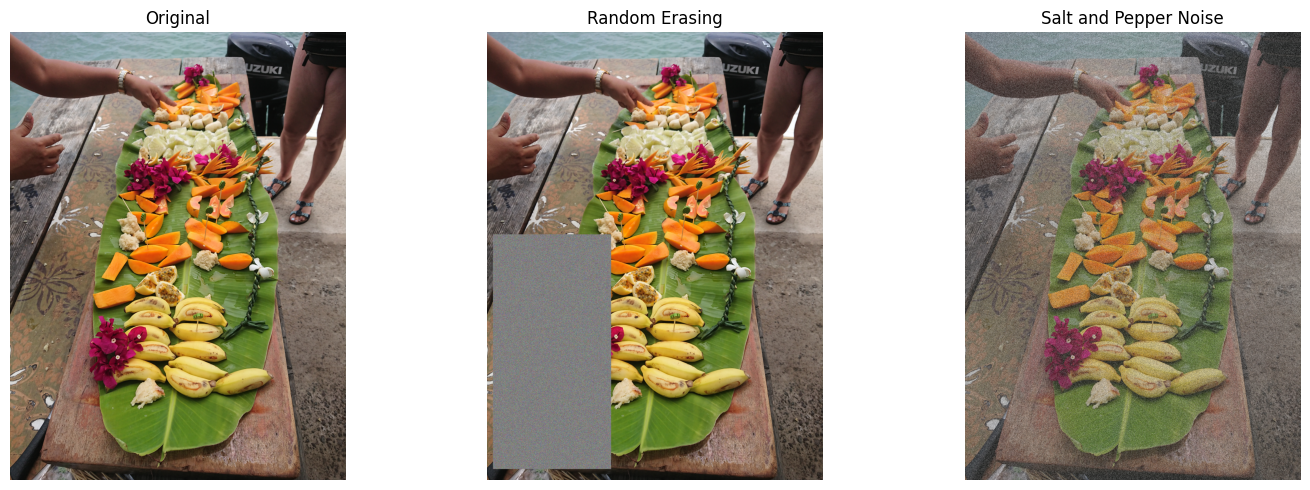

In [8]:
show_images([fruits, random_erased, noisy], ['Original', 'Random Erasing', 'Salt and Pepper Noise'])

## Day 12: Define Augmentation Use Case

As stated in the introduction, my chosen use case is detecting birds in the wild. The isles of Polynesia are home to 175 species of birds, of which 41 are endemic and 35 are endangered. (source: https://en.wikipedia.org/wiki/List_of_birds_of_French_Polynesia).
Finding their nesting places is crucial for conservation efforts, so using deep learning to detect them in the wild could be a valuable tool for researchers and conservationists.
As for my augmentation methods, I chose random erasing to handle occlusion, as birds may be partially hidden by branches or leaves. As for adding noise, I chose salt and pepper noise to simulate the effect of low-quality images or poor lighting conditions, which could be common in outdoor environments if people do not use expensive cameras.
